#### The delay time distributions for WDWD and NSNS systems that merge within a Hubble Time

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

Similarly to the formation efficiencies our systems of interest are those that merge in a Hubble Time and are 
1) two neutron stars (NSNS)
2) a carbon oyxygen white dwarf and any white dwarf (COWD+WD)

We will use the DCOmask filter to help us select for these systems, and then booleans to make further selections.
We will use the NSNS optimized run to analyze the delay time distribution for the NSNS systems, and the WDWD optimized run to look at the delay time distribution for the COWD+WD systems.

In [33]:
# let's read in our files for the fiducial case

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [34]:
## gathering data
# merging conditions
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers = Merges_Hubble_Time == True

# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixture_weights_merged = mixture_weights_all[DCO_mask_NSNS*condition_mergers]

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes_merged = lifetimes_all[DCO_mask_NSNS*condition_mergers]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times_merged = col_times_all[DCO_mask_NSNS*condition_mergers]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_all = lifetimes_all + col_times_all
delay_times_merged = lifetimes_merged + col_times_merged

In [35]:
# masking for NSNS systems
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_merged = stellar_types_all_1[DCO_mask_NSNS*condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_merged = stellar_types_all_2[DCO_mask_NSNS*condition_mergers]

# NSNS bool
NSNS_systems_bool_merged = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

In [36]:
# getting the delay time info just for these NSNS systems
delay_times_merged_NSNS = delay_times_merged[NSNS_systems_bool_merged]
mixture_weights_merged_NSNS = mixture_weights_merged[NSNS_systems_bool_merged]

### Let's do the same for the WDWD optimized run

In [2]:
## WDWD optimized run

# let's first look at the NSNS_output
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# merging conditions
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers_WDopt = Merges_Hubble_Time_WDopt == True

# making sure we are rpesenting the true universe
mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixture_weights_merged_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# times (these should be in Myr)
lifetimes_all_WDopt = DCOs_WDWD['Time'][()]
lifetimes_merged_WDopt = lifetimes_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

col_times_all_WDopt = DCOs_WDWD['Coalescence_Time'][()]
col_times_merged_WDopt = col_times_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_all_WDopt = lifetimes_all_WDopt + col_times_all_WDopt
delay_times_merged_WDopt = lifetimes_merged_WDopt + col_times_merged_WDopt

In [4]:
# masking for COWD+WD systems
stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_merged_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

stellar_types_all_2_WDopt = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_merged_WDopt = stellar_types_all_2_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# gathering the masses
mass_1_all = DCOs_WDWD['Mass(1)'][()]
mass_1_merged = mass_1_all[DCO_mask_WDWD*condition_mergers_WDopt]

mass_2_all = DCOs_WDWD['Mass(2)'][()]
mass_2_merged = mass_2_all[DCO_mask_WDWD*condition_mergers_WDopt]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1 = np.maximum(mass_1_merged, mass_2_merged)
M2 = np.minimum(mass_1_merged, mass_2_merged)

In [5]:
# let's find the bools for each of our progenitor systems

# WDWD bool with at least one COWD + COWD/HeWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(COHeWD_bool_WDWD, np.logical_or(COWD_bool_WDWD, HeCOWD_bool_WDWD))

# violent merger - unequal mass + COWD+COWD
mass_unequal_conditon = mass_1_merged >= 1.0
violent_merger_unequal_bool = mass_unequal_conditon*COWD_bool_WDWD

# violent merger - equal mass (q_cr = 0.9) + COWD+COWD
mass_min_criteria = np.logical_and(mass_1_merged>=0.8, mass_2_merged>=0.8)
critical_mass_ratio_bool = np.logical_and(M2/M1 >= 0.9, mass_min_criteria)
violent_merger_equal_bool = critical_mass_ratio_bool*COWD_bool_WDWD

# D6 HVS
SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass_1_merged, mass_2_merged)

# D6 - two explosion
mass_D6_condition = mass_1_merged < 1.0
d6_two_explosion = mass_D6_condition*carbon_oxygen_bool_WDWD_merged_WDopt

In [6]:
# delay time info for these masked systems

delay_times_merged_WDWD_WDopt = delay_times_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]
mixture_weights_merged_WDWD_WDopt = mixture_weights_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

delay_times_violent_unequal = delay_times_merged_WDopt[violent_merger_unequal_bool]
mixture_weights_violent_unequal = mixture_weights_merged_WDopt[violent_merger_unequal_bool]

delay_times_violent_equal = delay_times_merged_WDopt[violent_merger_equal_bool]
mixture_weights_violent_equal = mixture_weights_merged_WDopt[violent_merger_equal_bool]

delay_times_HVS = delay_times_merged_WDopt[SN_Ia_HVS]
mixture_weights_HVS = mixture_weights_merged_WDopt[SN_Ia_HVS]

delay_times_D6_two = delay_times_merged_WDopt[d6_two_explosion]
mixture_weights_D6_two = mixture_weights_merged_WDopt[d6_two_explosion]

### Plotting!

NameError: name 'delay_times_merged_NSNS' is not defined

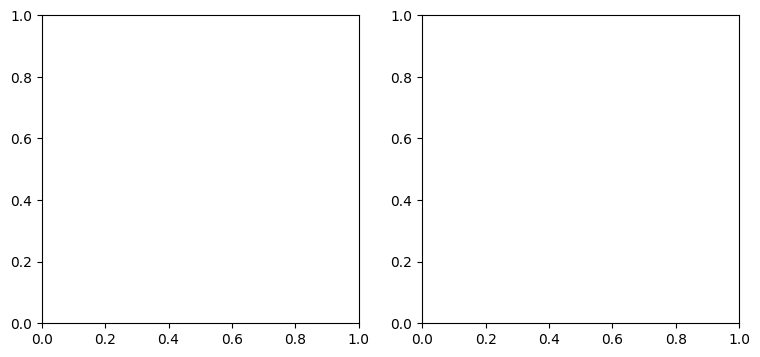

In [7]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(delay_times_merged_NSNS, weights=mixture_weights_merged_NSNS, bins=40, density=False)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
bin_widths = np.diff(bin_edges)

axs[0].plot(bin_centers, (hist/bin_widths), color=cset.pale_green, lw=3, label='NSNS merged')

# plt.yscale('log')
# plt.ylim(10**-8, 10**-5)

# axs[0].set_ylabel(r'$\mathrm{dN/d}\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$t_{\mathrm{delay}}[Myr^{-1}]$', fontsize=15)
axs[0].set_ylabel(r'$\mathrm{\Delta} N/\mathrm{\Delta} T_{\mathrm{delay}} [\mathrm{Myr^{-1}}]$', fontsize=15)

axs[0].legend()

# COWD+WD
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(delay_times_merged_WDWD_WDopt, weights=mixture_weights_merged_WDWD_WDopt, bins=40, density=False)

bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2
bin_wdiths_WDopt = np.diff(bin_edges_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_WDopt, hist_WDWD_WDopt/bin_wdiths_WDopt, color=cset.pale_blue, lw=3, label='COWD+WD merged')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$t_{\mathrm{delay}}[Myr^{-1}]$', fontsize=15)

axs[1].legend(loc='upper left')

fig.suptitle('Delay Time Distributions')

Text(0.5, 1.0, 'Delay Time Distributions')

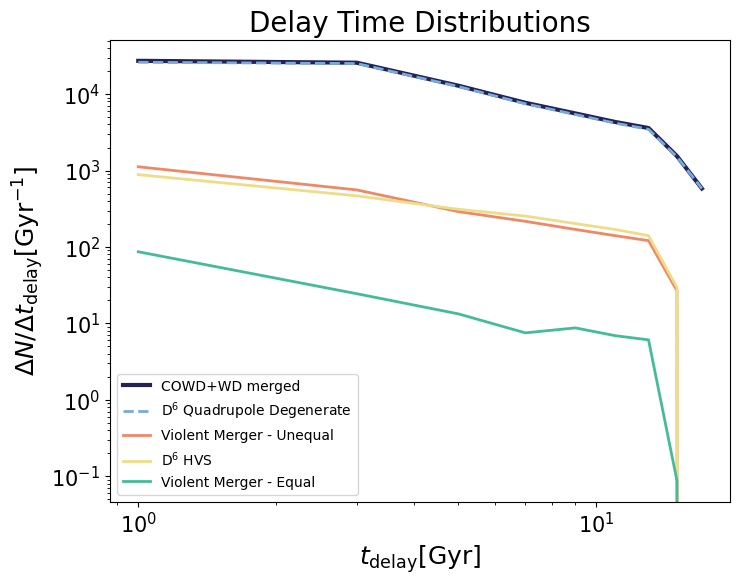

In [17]:
# plotting delay time dist
fig, axs = plt.subplots(figsize=(8, 6))

cset = tc.dark
cset_l = tc.light

# COWD+WD
bins_WDWD = np.arange(0,20,2)

delay_times_merged_WDWD_WDopt_Gyr = delay_times_merged_WDWD_WDopt*(10**-3)
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(delay_times_merged_WDWD_WDopt_Gyr, weights=mixture_weights_merged_WDWD_WDopt, bins=bins_WDWD, density=False)

binwidth_WDWD = np.diff(bins_WDWD)
bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2

axs.plot(bin_centers_WDWD_WDopt, (hist_WDWD_WDopt/binwidth_WDWD), color=cset.dark_blue, lw=3, label='COWD+WD merged')


# D^6 - two star explosion

bins_WDWD_D6_two = np.arange(0,20,2)

delay_times_D6_two_Gyr = delay_times_D6_two*(10**-3)
hist_D6_two, bin_edges_D6_two = np.histogram(delay_times_D6_two_Gyr, weights=mixture_weights_D6_two, bins=bins_WDWD_D6_two, density=False)

binwidth_D6_two = np.diff(bins_WDWD_D6_two)
bin_centers_D6_two = (bin_edges_D6_two[0:-1] + bin_edges_D6_two[1:])/2

axs.plot(bin_centers_D6_two, (hist_D6_two/binwidth_D6_two), color=cset_l.light_blue, lw=2, ls='--', label='$\mathrm{D^6}$ Quadrupole Degenerate')


# violent merger - unequal

bins_WDWD_vm_unequal = np.arange(0,20,2)

delay_times_violent_unequal_Gyr = delay_times_violent_unequal*(10**-3)
hist_vm_unequal, bin_edges_vm_unequal = np.histogram(delay_times_violent_unequal_Gyr, weights=mixture_weights_violent_unequal, bins=bins_WDWD_vm_unequal, density=False)

binwidth_vm_unequal = np.diff(bins_WDWD_vm_unequal)
bin_centers_vm_unequal = (bin_edges_vm_unequal[0:-1] + bin_edges_vm_unequal[1:])/2

axs.plot(bin_centers_vm_unequal, (hist_vm_unequal/binwidth_vm_unequal), color=cset_l.orange, lw=2, label='Violent Merger - Unequal')

# D^6 HVS

bins_WDWD_HVS = np.arange(0,20,2)

delay_times_HVS_Gyr = delay_times_HVS*(10**-3)
hist_HVS, bin_edges_HVS = np.histogram(delay_times_HVS_Gyr, weights=mixture_weights_HVS, bins=bins_WDWD_HVS, density=False)

binwidth_HVS = np.diff(bins_WDWD_HVS)
bin_centers_HVS = (bin_edges_HVS[0:-1] + bin_edges_HVS[1:])/2

axs.plot(bin_centers_HVS, (hist_HVS/binwidth_HVS), color=cset_l.light_yellow, lw=2, label='$\mathrm{D^6}$ HVS')


# violent merger - equal

bins_WDWD_vm_equal = np.arange(0,20,2)

delay_times_violent_equal_Gyr = delay_times_violent_equal*(10**-3)
hist_vm_equal, bin_edges_vm_equal = np.histogram(delay_times_violent_equal_Gyr, weights=mixture_weights_violent_equal, bins=bins_WDWD_vm_equal, density=False)

binwidth_vm_equal = np.diff(bins_WDWD_vm_equal)
bin_centers_vm_equal = (bin_edges_vm_equal[0:-1] + bin_edges_vm_equal[1:])/2

axs.plot(bin_centers_vm_equal, (hist_vm_equal/binwidth_vm_equal), color=cset_l.mint, lw=2, label='Violent Merger - Equal')






axs.set_ylabel(r'$\mathrm{\Delta} N/\mathrm{\Delta} t_{\mathrm{delay}} [\mathrm{Gyr^{-1}}]$', fontsize=18)
# axs[0].set_ylabel(r'Counts', fontsize=15)
axs.set_xlabel(r'$t_{\mathrm{delay}}[\mathrm{Gyr}]$', fontsize=18)
axs.tick_params(axis='both', labelsize=15)
axs.legend()

axs.set_yscale('log')
axs.set_xscale('log')
# axs.legend(loc='upper left')

axs.set_title('Delay Time Distributions', fontsize=20)

# plt.subplots_adjust(wspace=0.4) # add padding between plots

## save figure:
# plt.savefig("../figures/delay_time_dist_log.png",bbox_inches='tight',pad_inches=0.1)

#### Counts weighted by the formation efficiencies

We can also weight the x axis by the formation efficiences

### Getting the formation efficiences

In [8]:
### first for the NSNS optimized run
# let's find the minimum mass

DATA_SPS = Data_NSNS['BSE_System_Parameters']

mass_1 = DATA_SPS['Mass@ZAMS(1)'][()]
mass_2 = DATA_SPS['Mass@ZAMS(2)'][()]
m1min_NSNS = min(mass_1)
m1max_NSNS = max(mass_1)
m2min_NSNS = min(mass_2)
print(m1min_NSNS, m1max_NSNS, m2min_NSNS)

NameError: name 'Data_NSNS' is not defined

In [9]:
m_rep_per_binary = utils_from_others.analytical_star_forming_mass_per_binary_using_kroupa_imf(5, 150, 0.1, 0.7)
n_binaries = np.shape(Data_NSNS['BSE_System_Parameters']['SEED'][()])[0]

total_mass_evolved_compas = n_binaries * m_rep_per_binary

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


NameError: name 'Data_NSNS' is not defined

In [10]:
formation_efficiencies_NSNS = mixture_weights_merged_NSNS/total_mass_evolved_compas

NameError: name 'mixture_weights_merged_NSNS' is not defined

In [7]:
### now the WDWD opimitized case

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

# let's find the minimum mass
mass_1_WDWD = DATA_SPS_WDWD['Mass@ZAMS(1)'][()]
mass_2_WDWD = DATA_SPS_WDWD['Mass@ZAMS(2)'][()]
m1min_WDWD = min(mass_1_WDWD)
m1max_WDWD = max(mass_1_WDWD)
m2min_WDWD = min(mass_2_WDWD)
print(m1min_WDWD, m1max_WDWD, m2min_WDWD)

1.0000013114546709 149.84690074731307 0.10001294195257501


In [8]:
m_rep_per_binary_WDWD = utils_from_others.analytical_star_forming_mass_per_binary_using_kroupa_imf(1, 150, 0.1, 0.7)
n_binaries_WDWD = np.shape(Data_WDWD['BSE_System_Parameters']['SEED'][()])[0]

total_mass_evolved_compas_WDWD = n_binaries_WDWD * m_rep_per_binary_WDWD

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


In [9]:
# formation efficiencies 
formation_efficiencies_COWD_WDopt = mixture_weights_merged_WDWD_WDopt/total_mass_evolved_compas_WDWD

formation_eff_violent_merger_unequal = mixture_weights_violent_unequal/total_mass_evolved_compas_WDWD

formation_eff_violent_merger_equal= mixture_weights_violent_equal/total_mass_evolved_compas_WDWD

formation_eff_HVS = mixture_weights_HVS/total_mass_evolved_compas_WDWD

formation_eff_D6_two = mixture_weights_D6_two/total_mass_evolved_compas_WDWD

## Plotting again!

NameError: name 'delay_times_merged_NSNS' is not defined

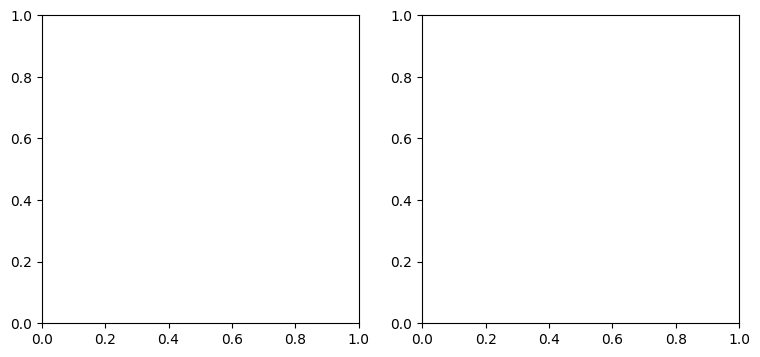

In [14]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
bins = np.arange(0,20,2) 
delay_times_merged_NSNS_Gyr = delay_times_merged_NSNS*(10**-3)
hist, bin_edges = np.histogram(delay_times_merged_NSNS_Gyr, weights=formation_efficiencies_NSNS, bins=bins, density=False)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
bin_widths = np.diff(bin_edges)

axs[0].plot(bin_centers, (hist/bin_widths)*1e6, color=cset.pale_green, lw=3, label='NSNS merged')
axs[0].set_xscale('log')

axs[0].set_ylabel(r'$\mathrm{\Delta} N/\mathrm{\Delta} t_{\mathrm{delay}} [\mathrm{Gyr^{-1}}10^6 \mathrm{M_\odot^{-1}}]$', fontsize=15)
# axs[0].set_ylabel(r'Counts', fontsize=15)
axs[0].set_xlabel(r'$t_{\mathrm{delay}}[\mathrm{Gyr}]$', fontsize=15)

axs[0].legend()

# COWD+WD
bins_WDWD = np.arange(0,20,2)

delay_times_merged_WDWD_WDopt_Gyr = delay_times_merged_WDWD_WDopt*(10**-3)
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(delay_times_merged_WDWD_WDopt_Gyr, weights=formation_efficiencies_COWD_WDopt, bins=bins_WDWD, density=False)

binwidth_WDWD = np.diff(bins_WDWD)
bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2

axs[1].plot(bin_centers_WDWD_WDopt, (hist_WDWD_WDopt/binwidth_WDWD)*1e6, color=cset.pale_blue, lw=3, label='COWD+WD merged')
axs[1].set_xscale('log')


# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$t_{\mathrm{delay}}[\mathrm{Gyr}]$', fontsize=15)

axs[1].legend(loc='upper left')

fig.suptitle('Delay Time Distributions')

plt.subplots_adjust(wspace=0.4) # add padding between plots

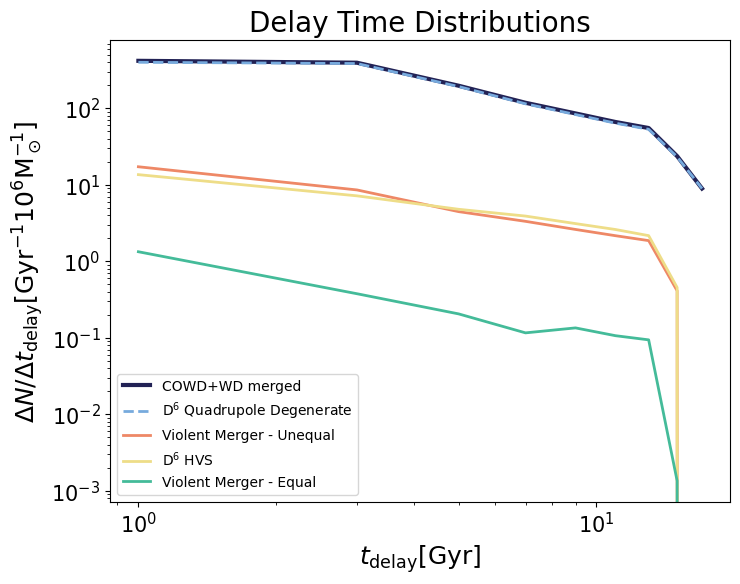

In [16]:
# plotting delay time dist
fig, axs = plt.subplots(figsize=(8, 6))

cset = tc.dark
cset_l = tc.light

# COWD+WD
bins_WDWD = np.arange(0,20,2)

delay_times_merged_WDWD_WDopt_Gyr = delay_times_merged_WDWD_WDopt*(10**-3)
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(delay_times_merged_WDWD_WDopt_Gyr, weights=formation_efficiencies_COWD_WDopt, bins=bins_WDWD, density=False)

binwidth_WDWD = np.diff(bins_WDWD)
bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2

axs.plot(bin_centers_WDWD_WDopt, (hist_WDWD_WDopt/binwidth_WDWD)*1e6, color=cset.dark_blue, lw=3, label='COWD+WD merged')


# D^6 - two star explosion

bins_WDWD_D6_two = np.arange(0,20,2)

delay_times_D6_two_Gyr = delay_times_D6_two*(10**-3)
hist_D6_two, bin_edges_D6_two = np.histogram(delay_times_D6_two_Gyr, weights=formation_eff_D6_two, bins=bins_WDWD_D6_two, density=False)

binwidth_D6_two = np.diff(bins_WDWD_D6_two)
bin_centers_D6_two = (bin_edges_D6_two[0:-1] + bin_edges_D6_two[1:])/2

axs.plot(bin_centers_D6_two, (hist_D6_two/binwidth_D6_two)*1e6, color=cset_l.light_blue, lw=2, ls='--', label='$\mathrm{D^6}$ Quadrupole Degenerate')


# violent merger - unequal

bins_WDWD_vm_unequal = np.arange(0,20,2)

delay_times_violent_unequal_Gyr = delay_times_violent_unequal*(10**-3)
hist_vm_unequal, bin_edges_vm_unequal = np.histogram(delay_times_violent_unequal_Gyr, weights=formation_eff_violent_merger_unequal, bins=bins_WDWD_vm_unequal, density=False)

binwidth_vm_unequal = np.diff(bins_WDWD_vm_unequal)
bin_centers_vm_unequal = (bin_edges_vm_unequal[0:-1] + bin_edges_vm_unequal[1:])/2

axs.plot(bin_centers_vm_unequal, (hist_vm_unequal/binwidth_vm_unequal)*1e6, color=cset_l.orange, lw=2, label='Violent Merger - Unequal')

# D^6 HVS

bins_WDWD_HVS = np.arange(0,20,2)

delay_times_HVS_Gyr = delay_times_HVS*(10**-3)
hist_HVS, bin_edges_HVS = np.histogram(delay_times_HVS_Gyr, weights=formation_eff_HVS, bins=bins_WDWD_HVS, density=False)

binwidth_HVS = np.diff(bins_WDWD_HVS)
bin_centers_HVS = (bin_edges_HVS[0:-1] + bin_edges_HVS[1:])/2

axs.plot(bin_centers_HVS, (hist_HVS/binwidth_HVS)*1e6, color=cset_l.light_yellow, lw=2, label='$\mathrm{D^6}$ HVS')


# violent merger - equal

bins_WDWD_vm_equal = np.arange(0,20,2)

delay_times_violent_equal_Gyr = delay_times_violent_equal*(10**-3)
hist_vm_equal, bin_edges_vm_equal = np.histogram(delay_times_violent_equal_Gyr, weights=formation_eff_violent_merger_equal, bins=bins_WDWD_vm_equal, density=False)

binwidth_vm_equal = np.diff(bins_WDWD_vm_equal)
bin_centers_vm_equal = (bin_edges_vm_equal[0:-1] + bin_edges_vm_equal[1:])/2

axs.plot(bin_centers_vm_equal, (hist_vm_equal/binwidth_vm_equal)*1e6, color=cset_l.mint, lw=2, label='Violent Merger - Equal')






axs.set_ylabel(r'$\mathrm{\Delta} N/\mathrm{\Delta} t_{\mathrm{delay}} [\mathrm{Gyr^{-1}}10^6 \mathrm{M_\odot^{-1}}]$', fontsize=18)
# axs[0].set_ylabel(r'Counts', fontsize=15)
axs.set_xlabel(r'$t_{\mathrm{delay}}[\mathrm{Gyr}]$', fontsize=18)
axs.tick_params(axis='both', labelsize=15)
axs.legend()

axs.set_yscale('log')
axs.set_xscale('log')
# axs.legend(loc='upper left')

axs.set_title('Delay Time Distributions', fontsize=20)

# plt.subplots_adjust(wspace=0.4) # add padding between plots

## save figure:
# plt.savefig("../figures/delay_time_dist_log.png",bbox_inches='tight',pad_inches=0.1)

### Close the data file

In [31]:
Data_NSNS.close()
Data_WDWD.close()